# ML and DL

## Dependencies

In [62]:
import os
import random
import sys
import warnings

import dill
import numpy as np
import pandas as pd
import torch
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [63]:
warnings.filterwarnings("ignore")  # 忽略警告
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]  # 用来正常显示中文标签
plt.rcParams["axes.unicode_minus"] = False  # 用来正常显示负号

In [64]:
root_dir = "C:\\ML4GM"
outputs_dir = os.path.join(root_dir, "models")  # 输出路径
os.makedirs(outputs_dir, exist_ok=True)  # 创建数据目录

In [65]:
def save_pkl(filepath, data):
    # 保存模型
    with open(filepath, "wb") as fw:
        dill.dump(data, fw)
    print(f"[{filepath}] data saving...")

## Load and proc

In [66]:
data = pd.read_csv("C:\\ML4GM\\proc_data\\02_merge\\merged_data_cleaned.csv")  # 加载数据

data

,rgiid,year,dhdt,GLIMSId,CenLon,CenLat,Area,Zmin,Zmax,Zmed,...,3_tp,4_tp,5_tp,6_tp,7_tp,8_tp,9_tp,10_tp,11_tp,12_tp
0,RGI60-13.00062,2000,0.4247,G078112E35641N,78.1118,35.6407,2.222,5417,6011,5839,...,0.000586,0.000365,0.000449,0.000739,0.002704,0.002098,0.000432,0.000077,0.000264,0.000368
1,RGI60-13.00062,2001,0.4973,G078112E35641N,78.1118,35.6407,2.222,5417,6011,5839,...,0.000269,0.000451,0.000659,0.002461,0.001985,0.000929,0.000385,0.000111,0.000291,0.000361
2,RGI60-13.00062,2002,0.3004,G078112E35641N,78.1118,35.6407,2.222,5417,6011,5839,...,0.000421,0.000794,0.000548,0.000775,0.001459,0.003014,0.000896,0.000325,0.000123,0.000393
3,RGI60-13.00062,2003,0.1291,G078112E35641N,78.1118,35.6407,2.222,5417,6011,5839,...,0.000706,0.000823,0.000717,0.000891,0.000666,0.000790,0.000774,0.000079,0.000172,0.000327
4,RGI60-13.00062,2004,0.4655,G078112E35641N,78.1118,35.6407,2.222,5417,6011,5839,...,0.000467,0.000711,0.000561,0.001879,0.001524,0.001099,0.000096,0.000339,0.000117,0.000351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162015,RGI60-15.13117,2015,-0.9031,G081355E30440N,81.3550,30.4400,6.788,5696,6147,5994,...,0.002721,0.000848,0.000343,0.003376,0.003901,0.003269,0.000254,0.000284,0.000138,0.000260
162016,RGI60-15.13117,2016,-0.7985,G081355E30440N,81.3550,30.4400,6.788,5696,6147,5994,...,0.000775,0.000603,0.001093,0.001152,0.004095,0.003483,0.000724,0.000292,0.000036,0.000129
162017,RGI60-15.13117,2017,-0.7527,G081355E30440N,81.3550,30.4400,6.788,5696,6147,5994,...,0.000753,0.000996,0.001467,0.001640,0.006460,0.003423,0.001169,0.000184,0.000250,0.000557
162018,RGI60-15.13117,2018,-0.6610,G081355E30440N,81.3550,30.4400,6.788,5696,6147,5994,...,0.000640,0.000472,0.000846,0.000786,0.004369,0.006954,0.001828,0.000229,0.000209,0.000200


In [67]:
# 保留 data 含 rgiid/year 供后续按组划分；EDA 使用不含 ID 的 data_eda
data_eda = data.drop(columns=["rgiid", "year", "GLIMSId"], axis=1)
data_eda

,dhdt,CenLon,CenLat,Area,Zmin,Zmax,Zmed,Slope,Aspect,Lmax,...,3_tp,4_tp,5_tp,6_tp,7_tp,8_tp,9_tp,10_tp,11_tp,12_tp
0,0.4247,78.1118,35.6407,2.222,5417,6011,5839,21.5,358,1532,...,0.000586,0.000365,0.000449,0.000739,0.002704,0.002098,0.000432,0.000077,0.000264,0.000368
1,0.4973,78.1118,35.6407,2.222,5417,6011,5839,21.5,358,1532,...,0.000269,0.000451,0.000659,0.002461,0.001985,0.000929,0.000385,0.000111,0.000291,0.000361
2,0.3004,78.1118,35.6407,2.222,5417,6011,5839,21.5,358,1532,...,0.000421,0.000794,0.000548,0.000775,0.001459,0.003014,0.000896,0.000325,0.000123,0.000393
3,0.1291,78.1118,35.6407,2.222,5417,6011,5839,21.5,358,1532,...,0.000706,0.000823,0.000717,0.000891,0.000666,0.000790,0.000774,0.000079,0.000172,0.000327
4,0.4655,78.1118,35.6407,2.222,5417,6011,5839,21.5,358,1532,...,0.000467,0.000711,0.000561,0.001879,0.001524,0.001099,0.000096,0.000339,0.000117,0.000351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162015,-0.9031,81.3550,30.4400,6.788,5696,6147,5994,6.3,96,5519,...,0.002721,0.000848,0.000343,0.003376,0.003901,0.003269,0.000254,0.000284,0.000138,0.000260
162016,-0.7985,81.3550,30.4400,6.788,5696,6147,5994,6.3,96,5519,...,0.000775,0.000603,0.001093,0.001152,0.004095,0.003483,0.000724,0.000292,0.000036,0.000129
162017,-0.7527,81.3550,30.4400,6.788,5696,6147,5994,6.3,96,5519,...,0.000753,0.000996,0.001467,0.001640,0.006460,0.003423,0.001169,0.000184,0.000250,0.000557
162018,-0.6610,81.3550,30.4400,6.788,5696,6147,5994,6.3,96,5519,...,0.000640,0.000472,0.000846,0.000786,0.004369,0.006954,0.001828,0.000229,0.000209,0.000200


### 缺失值统计与处理

In [68]:
# 缺失值统计
missing_count = data.isnull().sum()
missing_pct = (data.isnull().sum() / len(data) * 100).round(2)
missing_df = pd.DataFrame({"缺失数": missing_count, "缺失占比%": missing_pct})
print("各列缺失值统计：")
print(missing_df[missing_df["缺失数"] > 0] if missing_count.sum() > 0 else "无缺失值，无需处理。")

if missing_count.sum() > 0:
    # 目标列 dhdt：删除目标为缺失的行
    data = data.dropna(subset=["dhdt"])
    # 特征列：按列用中位数填充
    data = data.fillna(data.median(numeric_only=True))
    print("已处理：目标缺失行已删除，特征缺失已用中位数填充。")

各列缺失值统计：
无缺失值，无需处理。


### Correlation

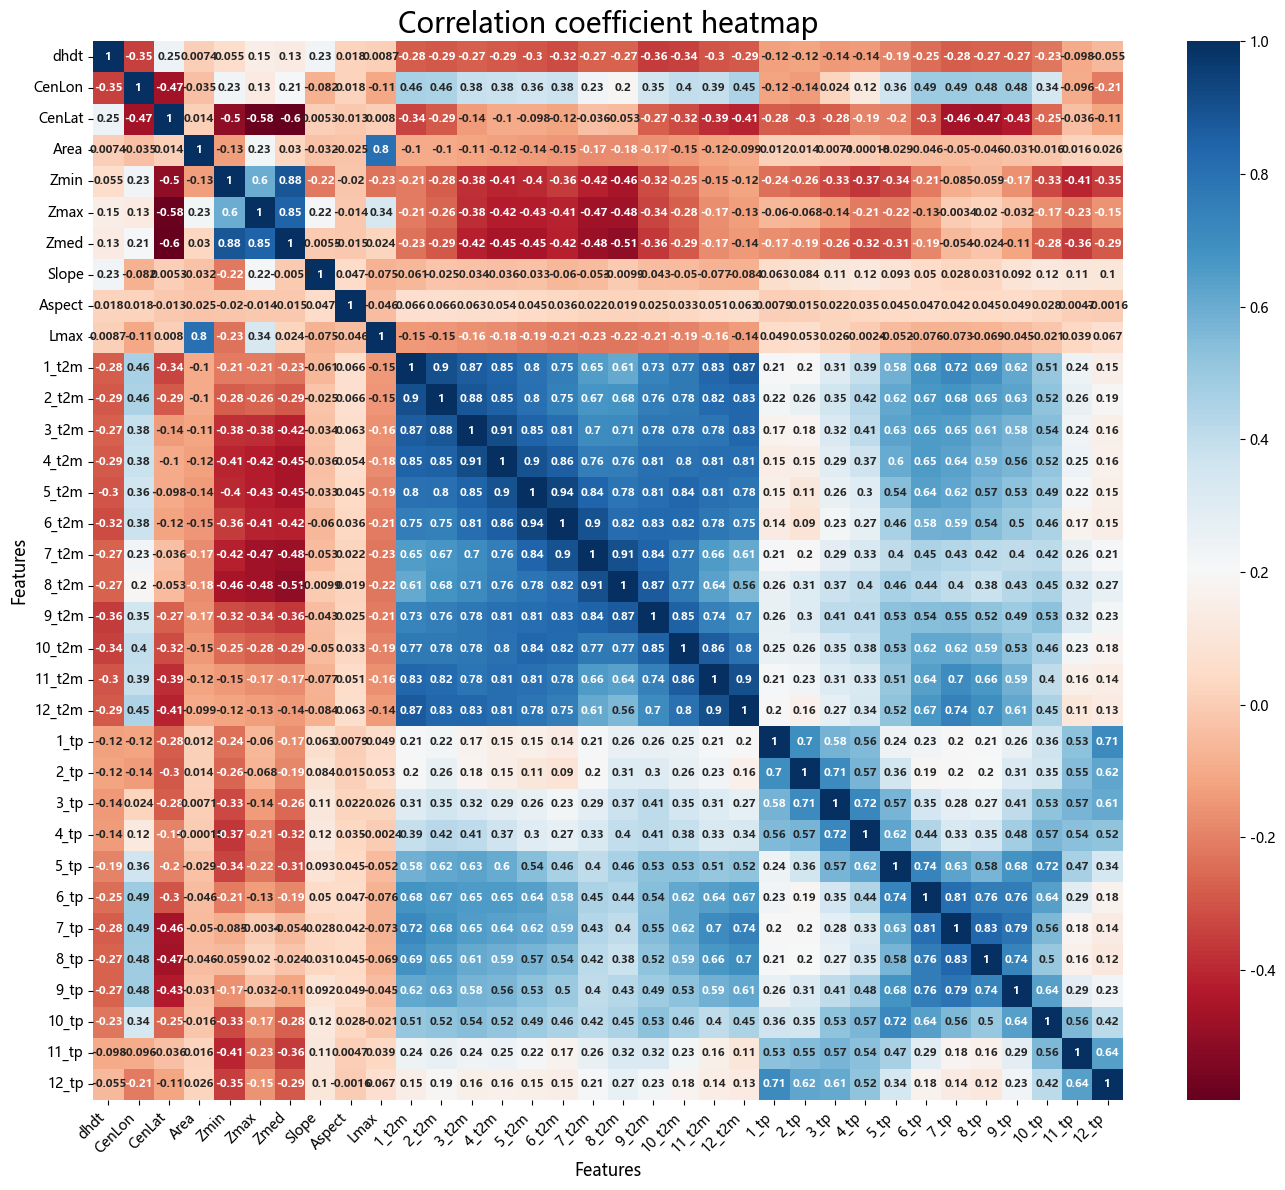

In [69]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 12), dpi=100)  # 定义画布
sns.heatmap(
    data_eda.corr(),
    annot=True,
    fmt=".2g",
    cmap="RdBu",
    annot_kws={"size": 8, "weight": "bold"},
    ax=ax,
)  # 绘制相关性图
ax.set_title("Correlation coefficient heatmap", fontsize=20)  # 标题
ax.set_xlabel("Features", fontsize=12)  # x轴标签
ax.set_ylabel("Features", fontsize=12)  # y轴标签
ax.tick_params(labelsize=10)  # 设置坐标轴轴刻度大小
plt.xticks(rotation=45, ha="right")
plt.tight_layout()  # 防重叠
plt.show()  # 显示图像
plt.close()  # 关闭图像

### 描述性统计

In [70]:
data_eda.describe()  # 描述性统计

,dhdt,CenLon,CenLat,Area,Zmin,Zmax,Zmed,Slope,Aspect,Lmax,...,3_tp,4_tp,5_tp,6_tp,7_tp,8_tp,9_tp,10_tp,11_tp,12_tp
count,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,...,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000,162020.000000
mean,-0.257627,81.365969,35.166028,8.165258,4603.146649,5790.578571,5176.448093,19.727799,164.274904,5065.648685,...,0.002034,0.002263,0.002261,0.003166,0.004343,0.004023,0.002780,0.001440,0.001101,0.001113
std,0.444020,7.583510,4.260026,25.345166,701.806128,692.965048,637.623030,6.110652,128.604322,3941.587662,...,0.002040,0.002091,0.001917,0.002635,0.003495,0.002862,0.002301,0.001502,0.001200,0.001169
min,-4.957200,68.124651,27.550145,2.000000,521.000000,1141.000000,610.000000,4.000000,0.000000,465.000000,...,0.000036,0.000067,0.000046,0.000019,0.000010,0.000006,0.000002,0.000014,0.000001,0.000004
25%,-0.516800,75.758579,31.556688,2.634000,4056.000000,5421.000000,4802.000000,15.100000,39.000000,3103.000000,...,0.000655,0.000961,0.001051,0.001326,0.001863,0.002028,0.001278,0.000510,0.000289,0.000273
50%,-0.221550,79.009959,35.660000,3.780000,4685.000000,5862.000000,5265.000000,19.100000,137.000000,4022.000000,...,0.001309,0.001600,0.001760,0.002555,0.003490,0.003413,0.002137,0.000912,0.000702,0.000699
75%,0.028800,86.379000,37.925088,6.714000,5170.000000,6248.000000,5684.000000,23.700000,304.000000,5649.000000,...,0.002739,0.002881,0.002804,0.004216,0.005821,0.005297,0.003569,0.001794,0.001489,0.001581
max,4.147000,103.098000,45.235130,1077.958000,7069.000000,8799.000000,7555.000000,45.300000,360.000000,76460.000000,...,0.031523,0.045283,0.036151,0.036111,0.033629,0.028797,0.032645,0.017967,0.016481,0.018180


### 目标与主要特征分布

In [ ]:
# 扩展 preprocessed_data.pkl：增加全量数据与分组信息（用于 nested GroupKFold）
from pathlib import Path

pkl_path = os.path.join(outputs_dir, "preprocessed_data.pkl")
if Path(pkl_path).exists():
    _data_loaded = load_pkl(pkl_path) if "load_pkl" in globals() else dill.load(open(pkl_path, "rb"))

    # 依赖于前文已定义的 data/X/y 与 train/val/test 掩码
    _data_loaded["X_all"] = X
    _data_loaded["y_all"] = y

    # rgiid 分组（空间泛化）
    _data_loaded["rgiid_all"] = data["rgiid"].values
    _data_loaded["rgiid_train"] = data.loc[train_mask, "rgiid"].values
    _data_loaded["rgiid_val"] = data.loc[val_mask, "rgiid"].values
    _data_loaded["rgiid_test"] = data.loc[test_mask, "rgiid"].values

    # year 分组（时间外推/泛化）
    _data_loaded["year_all"] = data["year"].values
    _data_loaded["year_train"] = data.loc[train_mask, "year"].values
    _data_loaded["year_val"] = data.loc[val_mask, "year"].values
    _data_loaded["year_test"] = data.loc[test_mask, "year"].values

    save_pkl(pkl_path, _data_loaded)
    print("Updated preprocessed_data.pkl with X_all/y_all and rgiid/year groups for nested CV.")
else:
    print("preprocessed_data.pkl not found; run the previous cell to generate it first.")

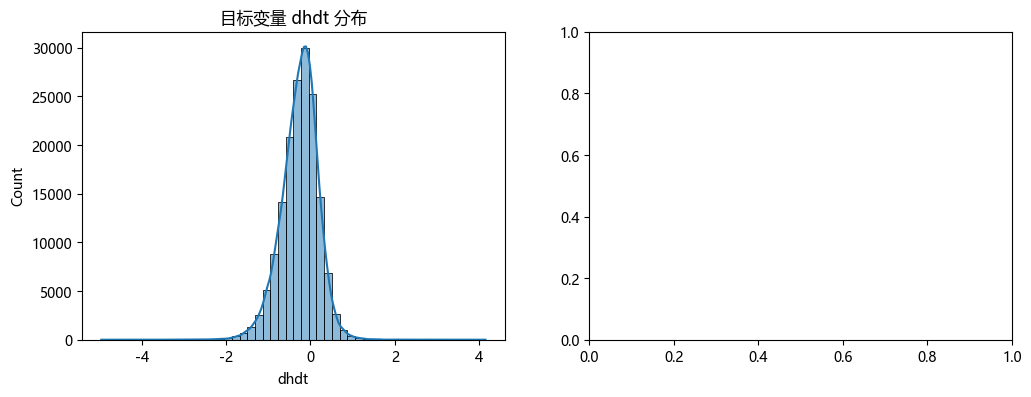

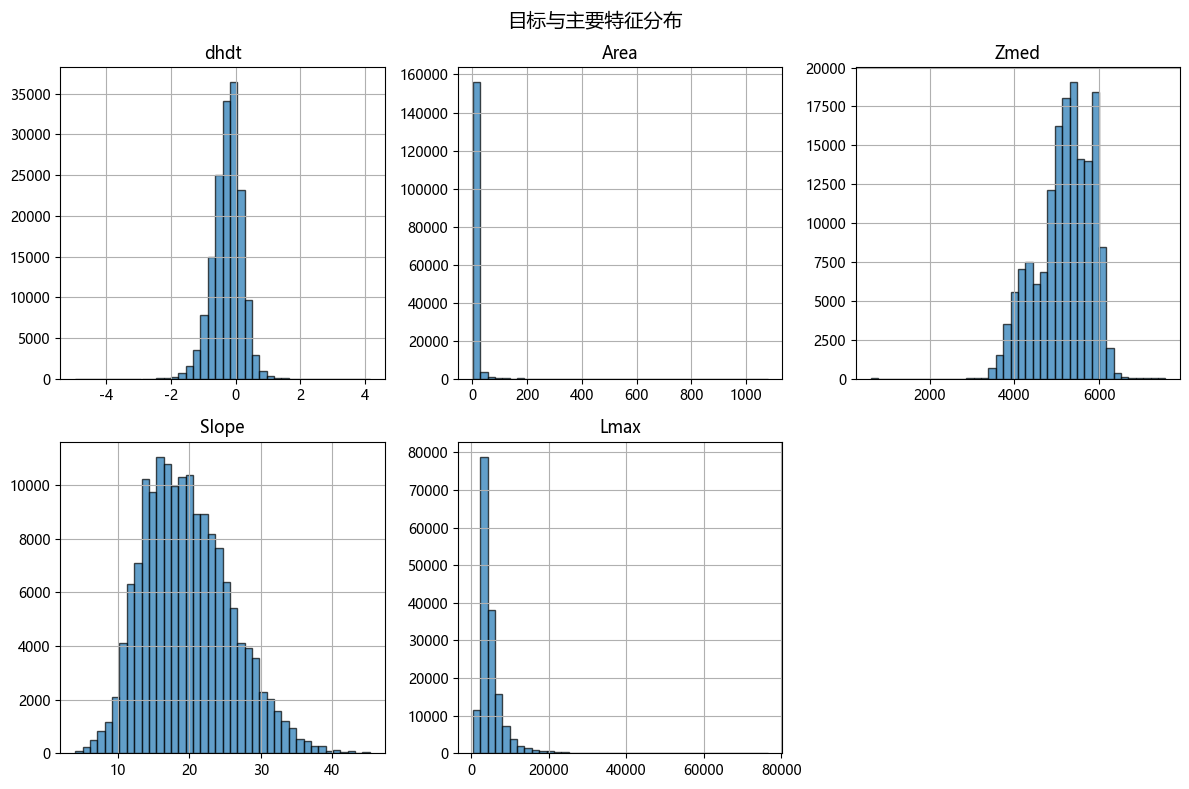

In [71]:
# 目标变量 dhdt 分布
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data_eda["dhdt"], kde=True, ax=axes[0], bins=50)
axes[0].set_title("目标变量 dhdt 分布")
axes[0].set_xlabel("dhdt")

# 主要特征分布（选取代表性列）
main_cols = ["dhdt", "Area", "Zmed", "Slope", "Lmax"]
data_eda[main_cols].hist(bins=40, figsize=(12, 8), layout=(2, 3), edgecolor="black", alpha=0.7)
plt.suptitle("目标与主要特征分布", fontsize=14)
plt.tight_layout()
plt.show()
plt.close()

### 异常值检查（可选）

dhdt: 异常值数量=3389, 占比=2.09%
Area: 异常值数量=17780, 占比=10.97%
Zmed: 异常值数量=320, 占比=0.2%
Lmax: 异常值数量=11840, 占比=7.31%


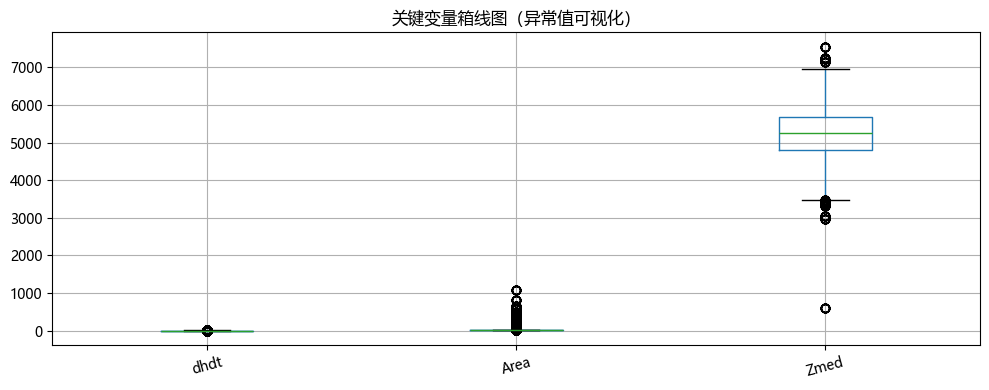

In [72]:
# IQR 异常值统计（仅检查，不删除）
check_cols = ["dhdt", "Area", "Zmed", "Lmax"]
for col in check_cols:
    Q1 = data_eda[col].quantile(0.25)
    Q3 = data_eda[col].quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((data_eda[col] < low) | (data_eda[col] > high)).sum()
    pct = (n_out / len(data_eda) * 100).round(2)
    print(f"{col}: 异常值数量={n_out}, 占比={pct}%")

# 关键变量箱线图
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
data_eda[["dhdt", "Area", "Zmed"]].boxplot(ax=ax)
ax.set_title("关键变量箱线图（异常值可视化）")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
plt.close()

### set x&y

In [73]:
feature_columns = data_eda.columns.tolist()[1:]  # 特征列
target_columns = data_eda.columns.tolist()[0]  # 目标列

X = data_eda[feature_columns].values  # 特征
y = data_eda[target_columns].values  # 目标

print(f"X shape: {X.shape}, y shape: {y.shape}")  # 打印维度

X shape: (162020, 33), y shape: (162020,)


### 划分策略（按组/时间，避免泄漏）

泛化对象：**新冰川**（按 `rgiid` 划分）或 **新年份**（按 `year` 划分），保证同一冰川或同一年不同时出现在训练集与测试集中。

In [74]:
# 按组划分：train/val/test = 80/10/10，避免同一组出现在多份数据中
split_by = "rgiid"  # 可选 "year"
train_ratio, val_ratio, test_ratio = 0.8, 0.1, 0.1
rs = np.random.RandomState(42)

unique_groups = data[split_by].unique()
rs.shuffle(unique_groups)
n = len(unique_groups)
n_train = max(1, int(n * train_ratio))
n_val = max(0, int(n * val_ratio))
n_test = max(1, n - n_train - n_val)
train_groups = set(unique_groups[:n_train])
val_groups = set(unique_groups[n_train : n_train + n_val])
test_groups = set(unique_groups[n_train + n_val :])

train_mask = data[split_by].isin(train_groups).values
val_mask = data[split_by].isin(val_groups).values
test_mask = data[split_by].isin(test_groups).values

X_train = X[train_mask]
X_val = X[val_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_val = y[val_mask]
y_test = y[test_mask]

print(f"划分依据: {split_by}, 训练组数: {len(train_groups)}, 验证组数: {len(val_groups)}, 测试组数: {len(test_groups)}")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

划分依据: rgiid, 训练组数: 6480, 验证组数: 810, 测试组数: 811
X_train shape: (129600, 33), y_train shape: (129600,)
X_val shape: (16200, 33), y_val shape: (16200,)
X_test shape: (16220, 33), y_test shape: (16220,)


### 数据标准化

In [75]:
X_scaler = StandardScaler()  # 定义标准化模型
X_train = X_scaler.fit_transform(X_train)  # 训练集标准化
X_val = X_scaler.transform(X_val)  # 验证集标准化
X_test = X_scaler.transform(X_test)  # 测试集标准化

save_pkl(os.path.join(outputs_dir, "X_scaler.pkl"), X_scaler)  # 保存模型

[C:\ML4GM\models\X_scaler.pkl] data saving...


In [76]:
y_scaler = StandardScaler()  # 定义标准化模型
y_train = y_scaler.fit_transform(y_train.reshape(-1, 1)).reshape(-1)  # 训练集标准化
y_val = y_scaler.transform(y_val.reshape(-1, 1)).reshape(-1)  # 验证集标准化（与训练/测试保持一致）
y_test = y_scaler.transform(y_test.reshape(-1, 1)).reshape(-1)  # 测试集标准化

save_pkl(os.path.join(outputs_dir, "y_scaler.pkl"), y_scaler)  # 保存模型

[C:\ML4GM\models\y_scaler.pkl] data saving...


In [77]:
# --- Save preprocessed data for 02-07 ---
_data = {
    "X_train": X_train, "X_val": X_val, "X_test": X_test,
    "y_train": y_train, "y_val": y_val, "y_test": y_test,
    "X_scaler": X_scaler, "y_scaler": y_scaler,
    "feature_columns": feature_columns,
    # Minimal metadata for reproducibility / consistent semantics
    "split_by": split_by,
    "train_ratio": train_ratio,
    "val_ratio": val_ratio,
    "test_ratio": test_ratio,
    "random_state": 42,
    "y_standardized": True,
}
save_pkl(os.path.join(outputs_dir, "preprocessed_data.pkl"), _data)
print("Preprocessed data saved to", os.path.join(outputs_dir, "preprocessed_data.pkl"))

[C:\ML4GM\models\preprocessed_data.pkl] data saving...
Preprocessed data saved to C:\ML4GM\models\preprocessed_data.pkl


In [78]:
print("pkl keys:", list(_data.keys()))
print("X_val/y_val:", "X_val" in _data, "y_val" in _data)

pkl keys: ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test', 'X_scaler', 'y_scaler', 'feature_columns']
X_val/y_val: True True
